In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

# Make plots a bit bigger
plt.rcParams["figure.figsize"] = (6, 6)

# Base directory
BASE_DIR = Path("/home/jovyan/work-easi-eds/data/compat/files/fc/p089r078")


In [2]:
img_files = sorted(BASE_DIR.glob("*.img"))

print(f"Found {len(img_files)} .img files:\n")
for f in img_files:
    print(f.name)


Found 136 .img files:

lztmre_p089r078_20151213_dc4fc.img
lztmre_p089r078_20160114_dc4fc.img
lztmre_p089r078_20160302_dc4fc.img
lztmre_p089r078_20160318_dc4fc.img
lztmre_p089r078_20160403_dc4fc.img
lztmre_p089r078_20160419_dc4fc.img
lztmre_p089r078_20160505_dc4fc.img
lztmre_p089r078_20160606_dc4fc.img
lztmre_p089r078_20160622_dc4fc.img
lztmre_p089r078_20160708_dc4fc.img
lztmre_p089r078_20160724_dc4fc.img
lztmre_p089r078_20160809_dc4fc.img
lztmre_p089r078_20160825_dc4fc.img
lztmre_p089r078_20160926_dc4fc.img
lztmre_p089r078_20161012_dc4fc.img
lztmre_p089r078_20161028_dc4fc.img
lztmre_p089r078_20161129_dc4fc.img
lztmre_p089r078_20161231_dc4fc.img
lztmre_p089r078_20170116_dc4fc.img
lztmre_p089r078_20170201_dc4fc.img
lztmre_p089r078_20170217_dc4fc.img
lztmre_p089r078_20170305_dc4fc.img
lztmre_p089r078_20170524_dc4fc.img
lztmre_p089r078_20170609_dc4fc.img
lztmre_p089r078_20170625_dc4fc.img
lztmre_p089r078_20170711_dc4fc.img
lztmre_p089r078_20170727_dc4fc.img
lztmre_p089r078_20170812_dc4fc.i

In [3]:
def load_single_band_img(path: Path):
    ds = gdal.Open(str(path), gdal.GA_ReadOnly)
    if ds is None:
        raise RuntimeError(f"Could not open {path}")

    if ds.RasterCount != 1:
        raise ValueError(f"{path.name} has {ds.RasterCount} bands (expected 1)")

    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()
    nodata = band.GetNoDataValue()

    ds = None
    return arr, nodata


Selected files:
  lztmre_p089r078_20190818_dc4fc.img
  lztmre_p089r078_20250903_dc4fc.img
  lztmre_p089r078_20250420_dc4fc.img


/env/lib/python3.12/site-packages/osgeo/gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


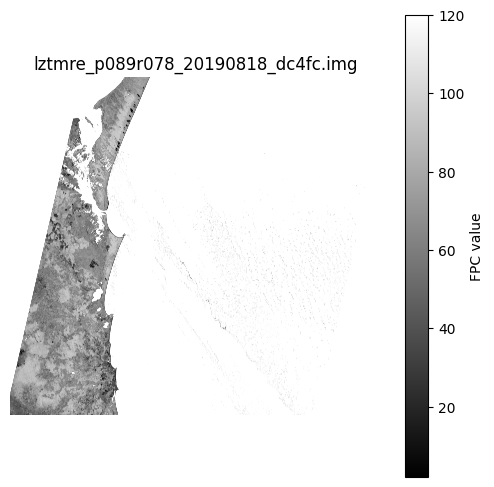

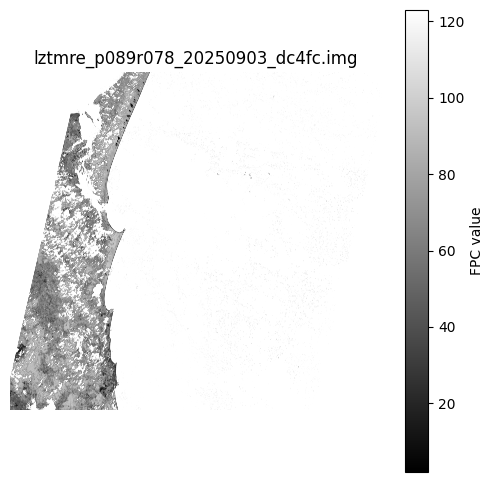

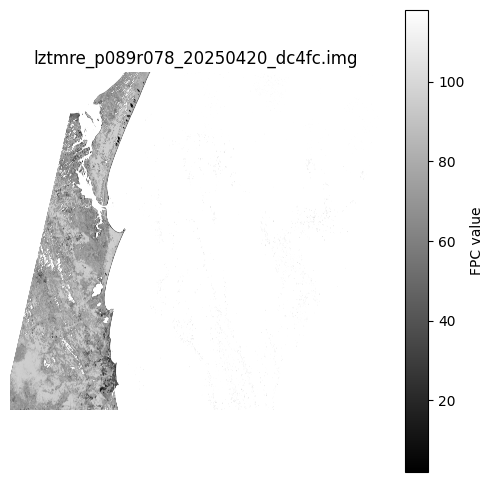

In [4]:
import random

# Choose 3 random files ONCE
random_imgs = random.sample(img_files, k=min(3, len(img_files)))

print("Selected files:")
for f in random_imgs:
    print(" ", f.name)

for img_path in random_imgs:
    arr, nodata = load_single_band_img(img_path)

    # Mask nodata for display
    if nodata is not None:
        arr = np.ma.masked_equal(arr, nodata)

    plt.figure()
    plt.imshow(arr, cmap="gray")
    plt.colorbar(label="FPC value")
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()


In [5]:
for img_path in random_imgs:
    arr, nodata = load_single_band_img(img_path)

    if nodata is not None:
        valid = arr[arr != nodata]
    else:
        valid = arr

    print(img_path.name)
    print(f"  min : {valid.min():.2f}")
    print(f"  max : {valid.max():.2f}")
    print(f"  mean: {valid.mean():.2f}")
    print(f"  std : {valid.std():.2f}")
    print("-" * 40)


lztmre_p089r078_20190818_dc4fc.img
  min : 2.00
  max : 120.00
  mean: 67.70
  std : 18.87
----------------------------------------
lztmre_p089r078_20250903_dc4fc.img
  min : 2.00
  max : 123.00
  mean: 68.53
  std : 20.37
----------------------------------------
lztmre_p089r078_20250420_dc4fc.img
  min : 2.00
  max : 118.00
  mean: 77.10
  std : 17.58
----------------------------------------


In [ ]:
from pathlib import Path
import numpy as np
from osgeo import gdal

p = Path("/home/jovyan/work-easi-eds/data/compat/files/fpc/p089r078/lztmre_p089r078_20190122_dc4fpc.img")

ds = gdal.Open(str(p))
b = ds.GetRasterBand(1)
arr = b.ReadAsArray()
nodata = b.GetNoDataValue()

print("File:", p.name)
print("dtype:", arr.dtype)
print("shape:", arr.shape)
print("nodata:", nodata)

print("min/max:", float(arr.min()), float(arr.max()))
print("unique (first 20):", np.unique(arr)[:20])

nz = int(np.count_nonzero(arr))
print("non-zero pixels:", nz, "of", arr.size, f"({100*nz/arr.size:.4f}%)")


In [ ]:
from pathlib import Path
import numpy as np
from osgeo import gdal
import glob

scene = "p089r078"
fc_root = Path("/home/jovyan/scratch/eds/tiles") / scene / "fc"

# pick one likely input (adjust pattern if needed)
candidates = sorted(glob.glob(str(fc_root / "**" / "*fcm*.tif"), recursive=True))
print("FC candidates:", len(candidates))
print("Example:", candidates[0] if candidates else "NONE FOUND")

fc_path = candidates[0]
ds = gdal.Open(fc_path)
print("FC file:", fc_path)
print("band count:", ds.RasterCount)

# green veg is often band 2 in FC products, but we'll inspect all bands quickly:
for i in range(1, ds.RasterCount + 1):
    b = ds.GetRasterBand(i)
    arr = b.ReadAsArray()
    nodata = b.GetNoDataValue()

    if nodata is not None:
        valid = arr[arr != nodata]
    else:
        valid = arr

    print(f"\nBand {i}")
    print("  dtype:", arr.dtype, "nodata:", nodata)
    print("  min/max:", float(valid.min()), float(valid.max()))
    print("  mean:", float(valid.mean()))


In [ ]:
for img_path in img_files:
    arr, nodata = load_single_band_img(img_path)

    # Mask nodata for display
    if nodata is not None:
        arr = np.ma.masked_equal(arr, nodata)

    plt.figure()
    plt.imshow(arr, cmap="gray")
    plt.colorbar(label="FPC value")
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()


In [ ]:
for img_path in img_files:
    arr, nodata = load_single_band_img(img_path)

    if nodata is not None:
        valid = arr[arr != nodata]
    else:
        valid = arr

    print(img_path.name)
    print(f"  min: {valid.min():.2f}")
    print(f"  max: {valid.max():.2f}")
    print(f"  mean: {valid.mean():.2f}")
    print("-" * 40)
